The two ray propagation model is implemented at varying levels of complexity.

Content:
1. Input parameters
2. Fresnel and FSPL functions
3. Models
    - 3.1 Advanced model (Poynting vector calculation)
    - 3.2 Coherent addition model (including reflection coefficient)
    - 3.3 Simplest model (reflection coefficient = -1)
4. Reflectivity coefficient analysis

Marcel van den Broek \
2024 

(updated may 2026)

In [182]:
import matplotlib.pyplot as plt
import numpy as np

Decibel to/from ratio conversion functions

In [183]:
def db_to_rat(db):
  return np.power(10, db/10)

def rat_to_db(rat):
    return 10 * np.log10(rat)

SECTION 1: Input parameters
__________________
First import the modulles and initialize the relevant constants and variables.

In [197]:
# constants
Z0      = 376.730313412                   # [Ohm] impedence vaccum
c       = 299792458                       # [m/s] speed of light

# initial conditions SI units
TX_h    = 15                             # [m] tranmitter height
RX_h    = 15                              # [m] receiver height
d_list  = np.geomspace(10, 100000, 2001)     # [m] horizontal seperation distance tx and rx
f       = 100e6                       # [Hz] frequency
Peirp   = 1                            # [W] transmitter power EIRP
e_r     = 15                              # [1] relative permittivity of medium
sigma   = 12e-3                           # [S/m] ground conductivity

# derived variables
lamda   = c / f                           # [m] wavelength
r_break = 4 * np.pi * TX_h * RX_h / lamda # [m] derived transition distance between r^-2 and r^-4 regions
print(r_break)

943.1302598782568


SECTION 2: Fresnel and FSPL functions
______________________________
Calculate the complex reflection coefficients given by Jordan and Balman, Electromagnetic Waves and Radiating Systems ed. 2 pages 631-632.

Note  that in this case the angle theta is already correctly given. The convention in reflection coefficients is to take theta as the angle between the incident ray and the normal. The current notation takes theta as the angle between the incident ray and the surface. The difference is a simple sin-cos switch.

In [208]:
# Jordan reflection equations
def fresnel(f, theta, e_r, sigma):
    x = 18 * 1e9 * sigma / f
    y = e_r - 1j * x
    gamma_perp = (np.sin(theta) - np.sqrt(y - np.cos(theta)**2)) / \
        (np.sin(theta) + np.sqrt(y - np.cos(theta)**2))
    gamma_par = (y * np.sin(theta) - np.sqrt(y - np.cos(theta)**2)) / \
        (y * np.sin(theta) + np.sqrt(y - np.cos(theta)**2))

    return gamma_perp, gamma_par

Free space propagation power density

In [209]:
def fspl(r, Peirp):
  return rat_to_db(Peirp / (4 * np.pi * r**2))

SECTION 3.1: Advanced model
_____________________
First we have the more complicated calculation. Plane waves and a polarization perpendicular to the ground plane are assumed in this case. It takes into account the reflection coefficient and the angle at which both waves combine (using Poynting vectors). The full derivation of this calculation is found in Marcel's notes.

not derived yet for TX_h < RX_h

In [210]:
def two_ray_advanced(TX_h, RX_h, d_list, f, Peirp, e_r, Z0, c):
  lamda = c / f 

  S_perp_list = [] # List containing the power densities at Rx
  S_par_list = []

  for d in d_list:
    # pre calculations
    theta = np.arctan((TX_h+RX_h)/d) # ground incidence angle (rads)
    # relative difference in angle of incidence LOS and REF paths at RX (rads) (check the derivation PDF for the meaning of phi1)
    if TX_h == RX_h:
      phi1 = theta
    elif TX_h > RX_h:
      phi1 = np.pi / 2 - np.arctan(d/(TX_h-RX_h)) + theta
    elif TX_h < RX_h:
      phi1 = theta - np.arctan((RX_h-TX_h)/d)
    else:
      print("Error in TX_h and RX_h")
      break

    E0 = np.sqrt(Peirp * Z0 / (4 * np.pi)) # E-field amplitude (V)
    r_los = np.sqrt(d**2 + (TX_h - RX_h)**2) # LOS path length (m)
    r_ref = np.sqrt(d**2 + (TX_h + RX_h)**2) # reflected path length (m)
    gamma_perp, gamma_par = fresnel(f, theta, e_r, sigma) # reflection coefficient Jordan
    # gamma_perp, gamma_par = fresnel(theta, e_r) # reflection coefficient Kraus


    # wave unit vector in the propagation direction
    k_los = np.array([1, 0, 0])
    k_ref = np.array([np.cos(phi1), np.sin(phi1), 0])

    # E-field components of both LOS and REF rays
    # Perpendicular
    E_los_z_perp = E0 / r_los * np.exp(1j * (2 * np.pi * r_los / lamda))
    E_ref_x_par = - E0 / r_ref * gamma_par * np.sin(phi1) * np.exp(1j * (2 * np.pi * r_ref / lamda))
    E_ref_y_par = E0 / r_ref * gamma_par * np.cos(phi1) * np.exp(1j * (2 * np.pi * r_ref / lamda))
    # Parallel
    E_los_y_par = E_los_z_perp
    E_ref_z_perp = E0 / r_ref * gamma_perp * np.exp(1j * (2 * np.pi * r_ref / lamda))

    # H-field calculation of LOS wave
    E_los_perp = np.array([0, 0, E_los_z_perp])
    E_los_par = np.array([0, E_los_y_par, 0])
    H_los_perp = np.cross(k_los, E_los_perp) / Z0 # plane wave assumption is implemented here as well by Z0 division
    H_los_par = np.cross(k_los, E_los_par) / Z0

    # H-field calculation of ref wave
    E_ref_perp = np.array([0, 0, E_ref_z_perp])
    E_ref_par = np.array([E_ref_x_par, E_ref_y_par, 0])
    H_ref_perp = np.cross(k_ref, E_ref_perp) / Z0
    H_ref_par = np.cross(k_ref, E_ref_par) / Z0

    # magnitude of the Poynting vector calculation of the combined LOS and REF rays
    # Perpendicular
    S_perp = np.cross((E_los_perp + E_ref_perp), (H_los_perp + H_ref_perp))
    S_perp_list.append(rat_to_db(np.linalg.norm(np.abs(S_perp))))
    # Parallel
    S_par = np.cross((E_los_par + E_ref_par), (H_los_par + H_ref_par))
    S_par_list.append(rat_to_db(np.linalg.norm(np.abs(S_par))))

  return S_perp_list, S_par_list

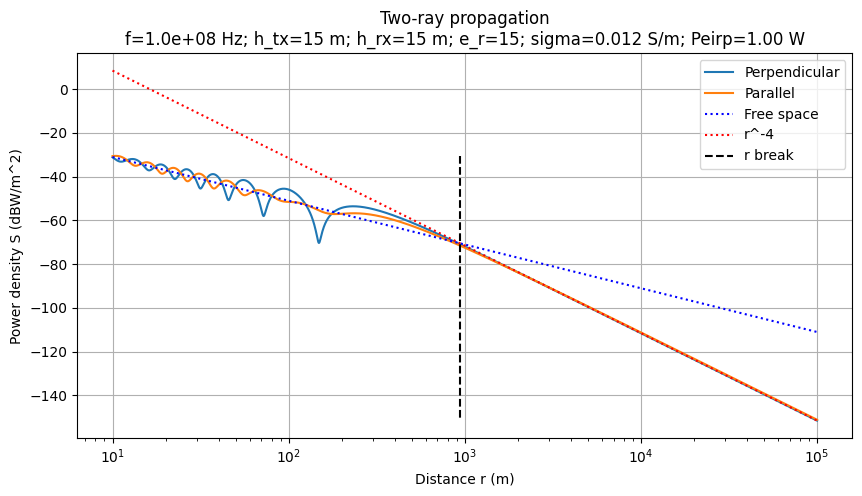

In [211]:
# 1/d fitting function
def func(d, a, b):
  return rat_to_db(a/d**b)

# calculate the power density at the receiver using the parameters from the input cell
S_perp_list, S_par_list = two_ray_advanced(TX_h, RX_h, d_list, f, Peirp, e_r, Z0, c)


# Plotting
fig, ax = plt.subplots(figsize=(10,5))

# Generate a plot with different e_r
# for e_r in [2, 5, 10, 50, 81, 500]:
#   S_perp_list, S_par_list = two_ray_advanced(TX_h, RX_h, d_list, f, Peirp, e_r, Z0)
#   ax.plot(d_list, S_perp_list, label=f'e_r = {e_r}')


ax.plot(d_list, S_perp_list, label='Perpendicular')
ax.plot(d_list, S_par_list, label='Parallel')
ax.plot(d_list, fspl(d_list, Peirp), 'b:', label='Free space')
ax.plot(d_list, func(d_list, Peirp*r_break**2/(4*np.pi), 4), 'r:', label='r^-4') # hand picked fitting parameters
ax.vlines(r_break, np.max(S_par_list), np.min(S_par_list), color='black', linestyles='dashed', label='r break')
# ax.vlines(8000, np.max(S_par_list), np.min(S_par_list), color='green', linestyles='dashed', label='8 km')
# ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Power density S (dBW/m^2)')
ax.set_xlabel('Distance r (m)')
ax.set_title(f'Two-ray propagation\nf={f:.1e} Hz; h_tx={TX_h} m; h_rx={RX_h} m; e_r={e_r}; sigma={sigma} S/m; Peirp={Peirp:.2f} W')
ax.legend()
ax.grid()


# download figs
save_name = f"two_ray_prop_adv_h{TX_h}_f{f*1e-6:.3f}.png"
plt.savefig(save_name)
plt.show()

Voor de PV opstellingen naast waterwegen heeft TNO een rapport uitgebracht waarin ze het twee stralen model gebruiken om te zien op welke afstand een maximale ruisverhoging van 3dB gerealiseerd wordt.


SECTION 3.2: Coherent addition model
______________
Simple two ray model with plane waves and coherently additive waves.

In [212]:

def two_ray_coherent_add(TX_h, RX_h, d_list, f, Peirp, e_r, Z0, sigma, c):
    S_perp_list = []
    S_par_list = []
    
    lamda = c / f
    E0 = np.sqrt(Peirp * Z0 / (4 * np.pi)) # E-field amplitude

    for d in d_list:
        theta = np.arctan((TX_h + RX_h) / d) # ground incidence angle (rads)
        r_los = np.sqrt(d**2 + (TX_h - RX_h)**2) # LOS path length (m)
        r_ref = np.sqrt(d**2 + (TX_h + RX_h)**2) # reflected path length (m)
        
        # reflection coefficient
        gamma_perp, gamma_par = fresnel(f, theta, e_r, sigma)
        
        # geometric phase difference
        phase_diff = 2 * np.pi * (r_ref - r_los) / lamda
        
        # Sum the complex waves E_tot = E_direct + E_reflected (assumed r_los ≈ r_ref ≈ d)
        E_tot_perp = (E0 / d) * (1 + gamma_perp * np.exp(1j * phase_diff))
        E_tot_par = (E0 / d) * (1 + gamma_par * np.exp(1j * phase_diff))
        
        # Calculate the power density at Rx
        S_perp = np.abs(E_tot_perp)**2 / Z0
        S_par = np.abs(E_tot_par)**2 / Z0
        
        S_perp_list.append(rat_to_db(S_perp))
        S_par_list.append(rat_to_db(S_par))

    return S_perp_list, S_par_list

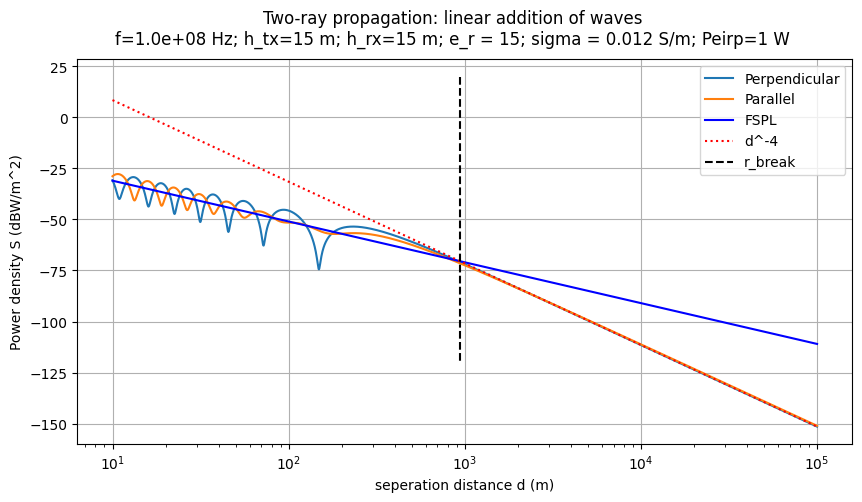

In [213]:
# fitting and plotting
def func(x, a, b):
  return rat_to_db(a/x**b)

# Calculation of power density using the coherent wave addition two ray model
S_perp_list, S_par_list = two_ray_coherent_add(TX_h, RX_h, d_list, f, Peirp, e_r, Z0, sigma, c)

# Plotting
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(d_list, S_perp_list, label='Perpendicular')
ax.plot(d_list, S_par_list, label='Parallel')
ax.plot(d_list, fspl(d_list, Peirp), 'b', label='FSPL')
ax.plot(d_list, func(d_list, Peirp*r_break**2/(4*np.pi), 4), 'r:', label='d^-4') # hand picked fitting parameters
ax.vlines(r_break, 20, -120, color='black', linestyles='dashed', label='r_break')
ax.set_ylabel('Power density S (dBW/m^2)')
ax.set_xlabel('seperation distance d (m)')
ax.set_xscale('log')
# ax.set_yscale('log')
ax.legend()
ax.grid()
plt.suptitle(f'Two-ray propagation: linear addition of waves\nf={f:.1e} Hz; h_tx={TX_h} m; h_rx={RX_h} m; e_r = {e_r}; sigma = {sigma} S/m; Peirp={Peirp} W')

# save_name = f"two_ray_prop_simp_h{TX_h}_f{f*1e-6:.3f}.png"
# plt.savefig(save_name)
# files.download(save_name)
plt.show()

SECTION 3.3: Simplest model
_________________
Simple two ray model with a reflection coefficient of -1, plane waves and coherent parallel waves that can be simply added.

In [214]:
def two_ray_simplest(TX_h, RX_h, d_list, f, Peirp, e_r, Z0):
  S_list = [] # List containing the power densities at Rx

  for d in d_list:
    # pre calculations
    E0 = np.sqrt(Peirp * Z0 / (4 * np.pi)) # E-field amplitude
    r_los = np.sqrt(d**2 + (TX_h - RX_h)**2) # LOS path length (m)
    r_ref = np.sqrt(d**2 + (TX_h + RX_h)**2) # reflected path length (m)

    E_tot = E0 * 2 / d * np.sin(np.pi * f * (r_ref - r_los) / c)
    pd = E_tot**2 / Z0
    S_list.append(rat_to_db(pd))
  return S_list



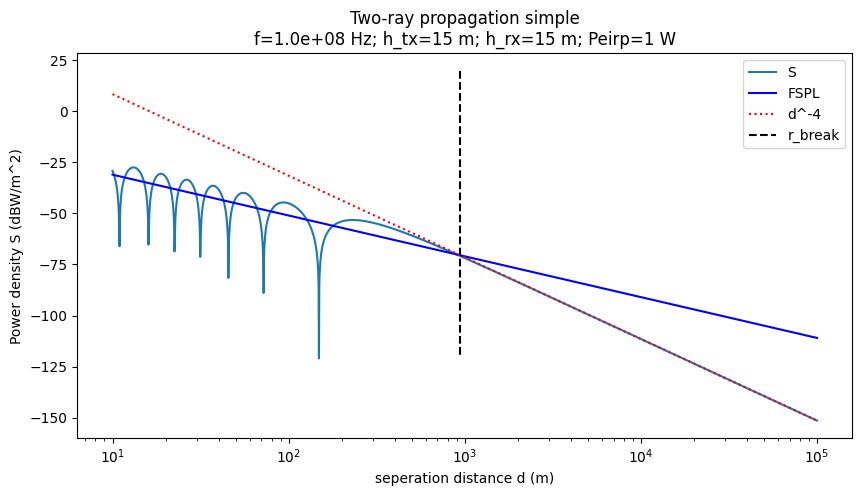

In [215]:
# fitting and plotting
def func(x, a, b):
  return rat_to_db(a/x**b)

# Calculating the power density
S_list = two_ray_simplest(TX_h, RX_h, d_list, f, Peirp, e_r, Z0)

# plotting
fig, ax = plt.subplots(figsize=(10,5))
ax.plot(d_list, S_list, label='S')
ax.plot(d_list, fspl(d_list, Peirp), 'b', label='FSPL')
ax.plot(d_list, func(d_list, Peirp*r_break**2/(4*np.pi), 4), 'r:', label='d^-4') # hand picked fitting parameters
ax.vlines(r_break, 20, -120, color='black', linestyles='dashed', label='r_break')
# ax.set_yscale('log')
ax.set_xscale('log')
ax.set_ylabel('Power density S (dBW/m^2)')
ax.set_xlabel('seperation distance d (m)')
ax.set_title(f'Two-ray propagation simple\nf={f:.1e} Hz; h_tx={TX_h} m; h_rx={RX_h} m; Peirp={Peirp} W')
ax.legend()
plt.show()

SECTION 4: Reflection coefficient analysis
__________________
Reflection coefficient analysis. Here the reflection coefficient is visualized to confirm that it is calculated correctly.

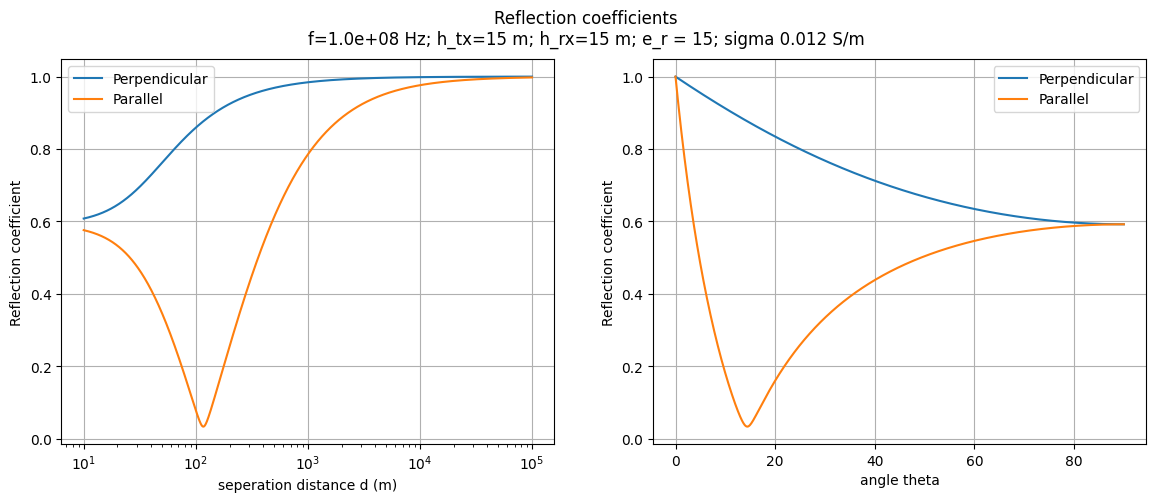

In [216]:
theta_list = np.linspace(0,np.pi/2,1000)
gamma_perp_list_d = []
gamma_par_list_d = []
gamma_perp_list_th = []
gamma_par_list_th = []

for d in d_list:
  theta = np.arctan((TX_h+RX_h)/d) # ground incidence angle (rads)
  gamma_perp, gamma_par = fresnel(f, theta, e_r, sigma)
  # gamma_perp, gamma_par = fresnel(theta, e_r)
  gamma_perp_list_d.append(gamma_perp)
  gamma_par_list_d.append(gamma_par)

for theta in theta_list:
  gamma_perp, gamma_par = fresnel(f, theta, e_r, sigma)
  # gamma_perp, gamma_par = fresnel(theta, e_r)
  gamma_perp_list_th.append(gamma_perp)
  gamma_par_list_th.append(gamma_par)


fig, ax = plt.subplots(1,2, figsize=(14,5))

# distance dependency
ax[0].plot(d_list, np.abs(gamma_perp_list_d), label='Perpendicular')
ax[0].plot(d_list, np.abs(gamma_par_list_d), label='Parallel')
ax[0].set_ylabel('Reflection coefficient')
ax[0].set_xlabel('seperation distance d (m)')
ax[0].set_xscale('log')
ax[0].grid()
ax[0].legend()

# angle depencency
ax[1].plot(theta_list/np.pi*180, np.abs(gamma_perp_list_th), label='Perpendicular')
ax[1].plot(theta_list/np.pi*180, np.abs(gamma_par_list_th), label='Parallel')
ax[1].set_ylabel('Reflection coefficient')
ax[1].set_xlabel('angle theta')
ax[1].grid()
# ax.set_xscale('log')
ax[1].legend()
plt.suptitle(f'Reflection coefficients\nf={f:.1e} Hz; h_tx={TX_h} m; h_rx={RX_h} m; e_r = {e_r}; sigma {sigma} S/m')
plt.show()

In [207]:
# DEPRECATED
# Kraus and Carver equations (See Kraus and Carver, Electromagnetics ed. 2 pages 456 and 458.)
# def fresnel(theta, e_r):
#   """The reflection factor according to Kraus and Carver"""
#   theta = np.pi / 2 - theta
#   gamma_perp = (np.cos(theta) - np.sqrt(e_r - np.sin(theta)**2)) / (np.cos(theta) + np.sqrt(e_r - np.sin(theta)**2)) # reflection coefficient perpendicular polarization

#   """"BEWARE: there seems to be some sort of fault with the equation below.
#   The equation in literature (Kraus) is the same as the equation below multiplied by -1.
#   However, this generates strange results.
#   Furthermore, as seen later in a testplot, the value of -1 is never reached/approached for the equation given in the source.
#   This is in contradiction with what the same literature states.
#   It's probably a sign mistake in the book."""
#   gamma_par = (np.sqrt(e_r) * np.cos(theta) - np.sqrt(e_r - np.sin(theta)**2)) / (np.sqrt(e_r) * np.cos(theta) + np.sqrt(e_r - np.sin(theta)**2)) # reflection coefficient perpendicular polarization
#   return gamma_perp, gamma_par